# Tello Experiment Metrics Report

This notebook turns the CSV files in `results/` into a compact experiment report.

It supports both CSV schemas used by the project:

1. **MetricsCollector CSV**: starts with `test_id,scenario,notes,run_mode,elapsed_ms,...`.
2. **State recording CSV**: starts with `state_sequence,timestamp_ms,recording_elapsed_ms,...`.

The goal is to separate likely causes of visible freezes or packet stalls:

- telemetry UDP gaps,
- video UDP gaps,
- Qt/control-panel rendering delays,
- state recording/export artifacts,
- recovery behavior after Wi-Fi or power interruptions.

Default input: `../results/*.csv`.

## How To Read This Notebook

Use the summary tables first, then inspect the plots for the runs that look suspicious.

Important fields:

- `telemetry_max_interarrival_ms`, `telemetry_gap_events_500ms`, `telemetry_gap_events_1000ms`
- `video_max_interarrival_ms`, `video_gap_events_500ms`, `video_gap_events_1000ms`
- `gui_vision_tick_delay_ms`, `gui_state_tick_delay_ms`, `plot_paint_ms`, `frame_convert_ms`, `frame_scale_ms`
- `plot_metric` and `event=plot_metric_changed:<metric>`
- state recording gaps computed from `recording_elapsed_ms`

Interpretation shortcut:

- telemetry gaps only: state/telemetry UDP issue.
- telemetry and video gaps together: likely Wi-Fi/system/network pause.
- no receiver gaps but state export gaps: recording/export path issue.
- GUI timing spikes without receiver gaps: rendering/event-loop issue.

In [1]:
from pathlib import Path
import csv
import math
from collections import defaultdict, Counter
import matplotlib.pyplot as plt

RESULTS_CANDIDATES = [Path("../results"), Path("results")]
RESULTS_DIR = next((p for p in RESULTS_CANDIDATES if p.exists()), RESULTS_CANDIDATES[0])
CSV_GLOB = "*.csv"

# Ignore Windows alternate data stream marker files if present under WSL.
CSV_FILES = sorted(p for p in RESULTS_DIR.glob(CSV_GLOB) if not p.name.endswith(":Zone.Identifier"))
print(f"Found {len(CSV_FILES)} CSV files in {RESULTS_DIR.resolve()}")
for p in CSV_FILES:
    print(f"- {p.name}")

Found 22 CSV files in /home/gabriel_fernandes/CS 500/results
- E-CMD-BASE-001.csv
- E-GUI-MOVE-001.csv
- E-GUI-PLOT-001.csv
- E-GUI-TEL-IDLE-001-state.csv
- E-GUI-TEL-IDLE-001.csv
- E-GUI-TEL-IDLE-002-metrics.csv
- E-GUI-TEL-IDLE-003-metrics - Copia.csv
- E-GUI-TEL-IDLE-003-metrics.csv
- E-GUI-TEL-IDLE-003-state.csv
- E-GUI-VID-IDLE-001.csv
- E-GUI-VID-IDLE-002-metrics.csv
- E-GUI-VID-IDLE-003-metrics.csv
- E-GUI-VID-IDLE-003-state.csv
- E-PWR-CYCLE-001.csv
- E-SMOKE-CMD-001.csv
- E-STATE-CLI-001.csv
- E-TEL-BASE-001.csv
- E-VID-BASE-001.csv
- E-VID-RESET-001.csv
- E-VIDEO-CLI-001.csv
- E-WIFI-LOSS-001.csv
- sample_metrics.csv


/home/gabriel_fernandes/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Helpers

In [2]:
def to_float(value, default=None):
    try:
        if value in (None, ""):
            return default
        x = float(value)
        return default if math.isnan(x) else x
    except Exception:
        return default


def to_int(value, default=0):
    x = to_float(value, None)
    return default if x is None else int(x)


def classify_header(header):
    h = set(header)
    if "elapsed_ms" in h and "run_mode" in h:
        return "metrics"
    if "recording_elapsed_ms" in h and "state_sequence" in h:
        return "state_recording"
    return "unknown"


def load_csv_report(path):
    # Keep only rows matching the header width. This detects accidental mixed files,
    # such as MetricsCollector rows appended into a state recording CSV.
    with path.open(newline="") as f:
        reader = csv.reader(f)
        header = next(reader, [])
        raw_rows = []
        malformed = []
        for line_no, row in enumerate(reader, start=2):
            if len(row) == len(header):
                raw_rows.append(dict(zip(header, row)))
            else:
                malformed.append({
                    "line": line_no,
                    "columns": len(row),
                    "preview": ",".join(row[:8]),
                })
    return {
        "path": path,
        "name": path.name,
        "header": header,
        "kind": classify_header(header),
        "rows": raw_rows,
        "malformed": malformed,
    }


def numeric(rows, field):
    vals = []
    for r in rows:
        x = to_float(r.get(field), None)
        if x is not None:
            vals.append(x)
    return vals


def last_value(rows, field, default=None):
    for r in reversed(rows):
        if field in r and r.get(field) not in (None, ""):
            return r.get(field)
    return default


def last_num(rows, field, default=0):
    return to_float(last_value(rows, field), default)


def max_num(rows, field, default=0):
    vals = numeric(rows, field)
    return max(vals) if vals else default


def label_for(report):
    rows = report["rows"]
    if rows and report["kind"] == "metrics":
        test_id = last_value(rows, "test_id", "") or ""
        scenario = last_value(rows, "scenario", "") or ""
        run_mode = last_value(rows, "run_mode", "") or ""
        label = " / ".join(x for x in [test_id, scenario, run_mode] if x)
        return label or report["path"].stem
    return report["path"].stem


def duration_ms(rows, field="elapsed_ms"):
    vals = numeric(rows, field)
    if not vals:
        return 0
    return max(vals) - min(vals)


def md_table(headers, rows):
    def fmt(x):
        if isinstance(x, float):
            return f"{x:.2f}"
        return str(x)
    lines = []
    lines.append("| " + " | ".join(headers) + " |")
    lines.append("|" + "|".join(["---"] * len(headers)) + "|")
    for row in rows:
        lines.append("| " + " | ".join(fmt(x) for x in row) + " |")
    return "\n".join(lines)


def show_markdown(text):
    try:
        from IPython.display import Markdown, display
        display(Markdown(text))
    except Exception:
        print(text)


reports = [load_csv_report(p) for p in CSV_FILES]
metrics_reports = [r for r in reports if r["kind"] == "metrics"]
state_reports = [r for r in reports if r["kind"] == "state_recording"]
unknown_reports = [r for r in reports if r["kind"] == "unknown"]

print(f"metrics files: {len(metrics_reports)}")
print(f"state recording files: {len(state_reports)}")
print(f"unknown files: {len(unknown_reports)}")

metrics files: 14
state recording files: 8
unknown files: 0


## File Inventory And Schema Health

In [3]:
rows = []
for r in reports:
    rows.append([
        r["name"],
        r["kind"],
        len(r["rows"]),
        len(r["header"]),
        len(r["malformed"]),
    ])
show_markdown(md_table(["file", "kind", "valid_rows", "columns", "malformed_rows"], rows))

bad = [r for r in reports if r["malformed"]]
if bad:
    print("\nFiles with malformed/mixed rows:")
    for r in bad:
        print(f"\n{r['name']}: {len(r['malformed'])} malformed rows")
        for item in r["malformed"][:8]:
            print(f"  line {item['line']}: {item['columns']} columns | {item['preview']}")
else:
    print("No malformed rows detected.")

| file | kind | valid_rows | columns | malformed_rows |
|---|---|---|---|---|
| E-CMD-BASE-001.csv | metrics | 58 | 58 | 0 |
| E-GUI-MOVE-001.csv | state_recording | 953 | 31 | 0 |
| E-GUI-PLOT-001.csv | state_recording | 720 | 31 | 5 |
| E-GUI-TEL-IDLE-001-state.csv | state_recording | 604 | 31 | 0 |
| E-GUI-TEL-IDLE-001.csv | metrics | 0 | 110 | 0 |
| E-GUI-TEL-IDLE-002-metrics.csv | state_recording | 604 | 31 | 0 |
| E-GUI-TEL-IDLE-003-metrics - Copia.csv | metrics | 3 | 110 | 0 |
| E-GUI-TEL-IDLE-003-metrics.csv | metrics | 3 | 110 | 0 |
| E-GUI-TEL-IDLE-003-state.csv | state_recording | 872 | 31 | 0 |
| E-GUI-VID-IDLE-001.csv | state_recording | 575 | 31 | 6 |
| E-GUI-VID-IDLE-002-metrics.csv | state_recording | 585 | 31 | 5 |
| E-GUI-VID-IDLE-003-metrics.csv | metrics | 81 | 110 | 0 |
| E-GUI-VID-IDLE-003-state.csv | state_recording | 976 | 31 | 0 |
| E-PWR-CYCLE-001.csv | metrics | 29 | 80 | 0 |
| E-SMOKE-CMD-001.csv | metrics | 1 | 58 | 0 |
| E-STATE-CLI-001.csv | metrics | 278 | 110 | 0 |
| E-TEL-BASE-001.csv | metrics | 60 | 58 | 0 |
| E-VID-BASE-001.csv | metrics | 59 | 58 | 0 |
| E-VID-RESET-001.csv | metrics | 44 | 80 | 0 |
| E-VIDEO-CLI-001.csv | metrics | 55 | 110 | 0 |
| E-WIFI-LOSS-001.csv | metrics | 44 | 78 | 0 |
| sample_metrics.csv | metrics | 5 | 58 | 0 |


Files with malformed/mixed rows:

E-GUI-PLOT-001.csv: 5 malformed rows
  line 351: 112 columns | 465,1782522675156,34,gui,,CONTROL_PANEL,100175,73
  line 352: 110 columns | ,gui,,CONTROL_PANEL,101175,74,1,1
  line 353: 110 columns | ,gui,,CONTROL_PANEL,102300,75,1,1
  line 354: 110 columns | ,gui,,CONTROL_PANEL,103424,76,1,1
  line 355: 12 columns | ,0,0,0,,,,

E-GUI-VID-IDLE-001.csv: 6 malformed rows
  line 300: 123 columns | 497,1782522444272,30002,0,0,3,0,0
  line 301: 110 columns | ,gui,,CONTROL_PANEL,88062,62,1,1
  line 302: 110 columns | ,gui,,CONTROL_PANEL,89183,63,1,1
  line 303: 110 columns | ,gui,,CONTROL_PANEL,90184,64,1,1
  line 304: 110 columns | ,gui,,CONTROL_PANEL,91184,65,1,1
  line 305: 22 columns | 0,83,10,0,54,137.06,0,17

E-GUI-VID-IDLE-002-metrics.csv: 5 malformed rows
  line 262: 129 columns | 330,1782523486908,25181,0,0,-3,0,0
  line 263: 110 columns | ,gui,,CONTROL_PANEL,73659,55,1,1
  line 264: 110 columns | ,gui,,CONTROL_PANEL,74776,56,1,1
  line 265: 110 col

## MetricsCollector Run Summary

In [4]:
summary = []
for r in metrics_reports:
    rows = r["rows"]
    if not rows:
        summary.append([r["name"], label_for(r), 0, 0, "", "", "", "", "", "", ""])
        continue
    summary.append([
        r["name"],
        label_for(r),
        len(rows),
        int(max_num(rows, "elapsed_ms", 0)),
        int(last_num(rows, "command_failures", 0)),
        int(max_num(rows, "telemetry_max_interarrival_ms", 0)),
        int(last_num(rows, "telemetry_gap_events_500ms", 0)),
        int(last_num(rows, "telemetry_gap_events_1000ms", 0)),
        int(max_num(rows, "video_max_interarrival_ms", 0)),
        int(last_num(rows, "video_gap_events_500ms", 0)),
        int(last_num(rows, "video_gap_events_1000ms", 0)),
    ])

show_markdown(md_table([
    "file", "label", "rows", "max_elapsed_ms", "cmd_fail",
    "tele_max_gap_ms", "tele_gap500", "tele_gap1000",
    "video_max_gap_ms", "video_gap500", "video_gap1000",
], summary))

| file | label | rows | max_elapsed_ms | cmd_fail | tele_max_gap_ms | tele_gap500 | tele_gap1000 | video_max_gap_ms | video_gap500 | video_gap1000 |
|---|---|---|---|---|---|---|---|---|---|---|
| E-CMD-BASE-001.csv | E-CMD-BASE-001 / command-baseline / WATCH | 58 | 61347 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
| E-GUI-TEL-IDLE-001.csv | E-GUI-TEL-IDLE-001 | 0 | 0 |  |  |  |  |  |  |  |
| E-GUI-TEL-IDLE-003-metrics - Copia.csv | gui / CONTROL_PANEL | 3 | 87925 | 0 | 378 | 0 | 0 | 0 | 0 | 0 |
| E-GUI-TEL-IDLE-003-metrics.csv | gui / CONTROL_PANEL | 3 | 87925 | 0 | 378 | 0 | 0 | 0 | 0 | 0 |
| E-GUI-VID-IDLE-003-metrics.csv | gui / CONTROL_PANEL | 81 | 120545 | 0 | 1607 | 1 | 1 | 1422 | 1 | 1 |
| E-PWR-CYCLE-001.csv | E-PWR-CYCLE-001 / power-cycle / VIDEO_WATCH | 29 | 41379 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
| E-SMOKE-CMD-001.csv | E-SMOKE-CMD-001 / command-smoke / ONCE | 1 | 98 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
| E-STATE-CLI-001.csv | E-STATE-CLI-001 / telemetry-cli-diagnostic / STATE_WATCH | 278 | 69308 | 0 | 151 | 0 | 0 | 0 | 0 | 0 |
| E-TEL-BASE-001.csv | E-TEL-BASE-001 / telemetry-baseline / STATE_WATCH | 60 | 59033 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
| E-VID-BASE-001.csv | E-VID-BASE-001 / video-baseline / VIDEO_WATCH | 59 | 60766 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
| E-VID-RESET-001.csv | E-VID-RESET-001 / stream-reset / VIDEO_WATCH | 44 | 47839 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
| E-VIDEO-CLI-001.csv | E-VIDEO-CLI-001 / video-cli-diagnostic / VIDEO_WATCH | 55 | 72153 | 0 | 0 | 0 | 0 | 54 | 0 | 0 |
| E-WIFI-LOSS-001.csv | E-WIFI-LOSS-001 / wifi-reconnect / WATCH | 44 | 62878 | 2 | 0 | 0 | 0 | 0 | 0 | 0 |
| sample_metrics.csv | E-SAMPLE / baseline / VIDEO_WATCH | 5 | 5000 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |

## State Recording Gap Summary

In [5]:
def state_samples(report):
    out = []
    for r in report["rows"]:
        seq = to_int(r.get("state_sequence"), None)
        t = to_int(r.get("recording_elapsed_ms"), None)
        if seq is None or t is None:
            continue
        out.append((t, seq, r))
    return out


def continuous_segments(samples):
    # Split when recording_elapsed_ms goes backwards, which usually means the
    # recording was restarted/cleared in the same exported file.
    segments = []
    cur = []
    prev = None
    for s in samples:
        if prev is not None:
            dt = s[0] - prev[0]
            if dt < 0:
                if len(cur) > 1:
                    segments.append(cur)
                cur = []
        cur.append(s)
        prev = s
    if len(cur) > 1:
        segments.append(cur)
    return segments


def gap_stats(samples):
    if len(samples) < 2:
        return {"rows": len(samples), "duration": 0, "max_gap": 0, "g300": 0, "g500": 0, "g1000": 0, "avg_gap": 0}
    gaps = [samples[i+1][0] - samples[i][0] for i in range(len(samples)-1)]
    return {
        "rows": len(samples),
        "duration": samples[-1][0] - samples[0][0],
        "avg_gap": sum(gaps) / len(gaps),
        "max_gap": max(gaps),
        "g300": sum(g >= 300 for g in gaps),
        "g500": sum(g >= 500 for g in gaps),
        "g1000": sum(g >= 1000 for g in gaps),
    }

state_summary = []
for r in state_reports:
    samples = state_samples(r)
    segs = continuous_segments(samples)
    st = gap_stats(samples)
    state_summary.append([
        r["name"],
        len(samples),
        len(segs),
        int(st["duration"]),
        round(st["avg_gap"], 1),
        int(st["max_gap"]),
        st["g300"],
        st["g500"],
        st["g1000"],
        len(r["malformed"]),
    ])

show_markdown(md_table([
    "file", "state_rows", "segments", "duration_ms", "avg_gap_ms",
    "max_gap_ms", "gap>=300", "gap>=500", "gap>=1000", "malformed_rows",
], state_summary))

| file | state_rows | segments | duration_ms | avg_gap_ms | max_gap_ms | gap>=300 | gap>=500 | gap>=1000 | malformed_rows |
|---|---|---|---|---|---|---|---|---|---|
| E-GUI-MOVE-001.csv | 953 | 1 | 95907 | 100.70 | 1305 | 3 | 3 | 3 | 0 |
| E-GUI-PLOT-001.csv | 720 | 1 | 73990 | 102.90 | 2023 | 3 | 3 | 3 | 5 |
| E-GUI-TEL-IDLE-001-state.csv | 604 | 1 | 60777 | 100.80 | 1120 | 2 | 2 | 2 | 0 |
| E-GUI-TEL-IDLE-002-metrics.csv | 604 | 1 | 60761 | 100.80 | 1282 | 2 | 2 | 2 | 0 |
| E-GUI-TEL-IDLE-003-state.csv | 872 | 1 | 87119 | 100.00 | 1763 | 6 | 5 | 2 | 0 |
| E-GUI-VID-IDLE-001.csv | 575 | 1 | 62956 | 109.70 | 2541 | 5 | 5 | 5 | 6 |
| E-GUI-VID-IDLE-002-metrics.csv | 585 | 1 | 59694 | 102.20 | 2041 | 2 | 2 | 2 | 5 |
| E-GUI-VID-IDLE-003-state.csv | 976 | 1 | 97941 | 100.50 | 1340 | 3 | 3 | 3 | 0 |

## Top State Recording Gaps

In [6]:
for r in state_reports:
    samples = state_samples(r)
    if len(samples) < 2:
        continue
    gaps = [(samples[i+1][0] - samples[i][0], samples[i], samples[i+1]) for i in range(len(samples)-1)]
    top = sorted(gaps, reverse=True, key=lambda x: x[0])[:8]
    print(f"\n{r['name']}")
    for gap, prev_s, next_s in top:
        row = next_s[2]
        print(
            f"  gap={gap:5d} ms | elapsed {prev_s[0]} -> {next_s[0]} | "
            f"seq {prev_s[1]} -> {next_s[1]} | "
            f"h={row.get('h')} tof={row.get('tof')} vgz={row.get('vgz')}"
        )


E-GUI-MOVE-001.csv
  gap= 1305 ms | elapsed 83452 -> 84757 | seq 911 -> 912 | h=0 tof=51 vgz=-5
  gap= 1150 ms | elapsed 50146 -> 51296 | seq 577 -> 578 | h=10 tof=115 vgz=-14
  gap= 1127 ms | elapsed 16861 -> 17988 | seq 246 -> 247 | h=0 tof=10 vgz=0
  gap=  297 ms | elapsed 42218 -> 42515 | seq 496 -> 497 | h=0 tof=97 vgz=-1
  gap=  194 ms | elapsed 55856 -> 56050 | seq 626 -> 627 | h=0 tof=94 vgz=-2
  gap=  190 ms | elapsed 55644 -> 55834 | seq 624 -> 625 | h=0 tof=90 vgz=1
  gap=  188 ms | elapsed 40292 -> 40480 | seq 476 -> 477 | h=-120 tof=70 vgz=-5
  gap=  167 ms | elapsed 36874 -> 37041 | seq 441 -> 442 | h=-140 tof=58 vgz=4

E-GUI-PLOT-001.csv
  gap= 2023 ms | elapsed 34887 -> 36910 | seq 464 -> 485 | h=0 tof=10 vgz=0
  gap= 1170 ms | elapsed 49477 -> 50647 | seq 614 -> 615 | h=0 tof=10 vgz=0
  gap= 1160 ms | elapsed 16132 -> 17292 | seq 282 -> 283 | h=0 tof=10 vgz=0
  gap=  157 ms | elapsed 20407 -> 20564 | seq 315 -> 316 | h=0 tof=10 vgz=0
  gap=  149 ms | elapsed 42733 -> 

## Receiver Gap Timeline: Telemetry And Video

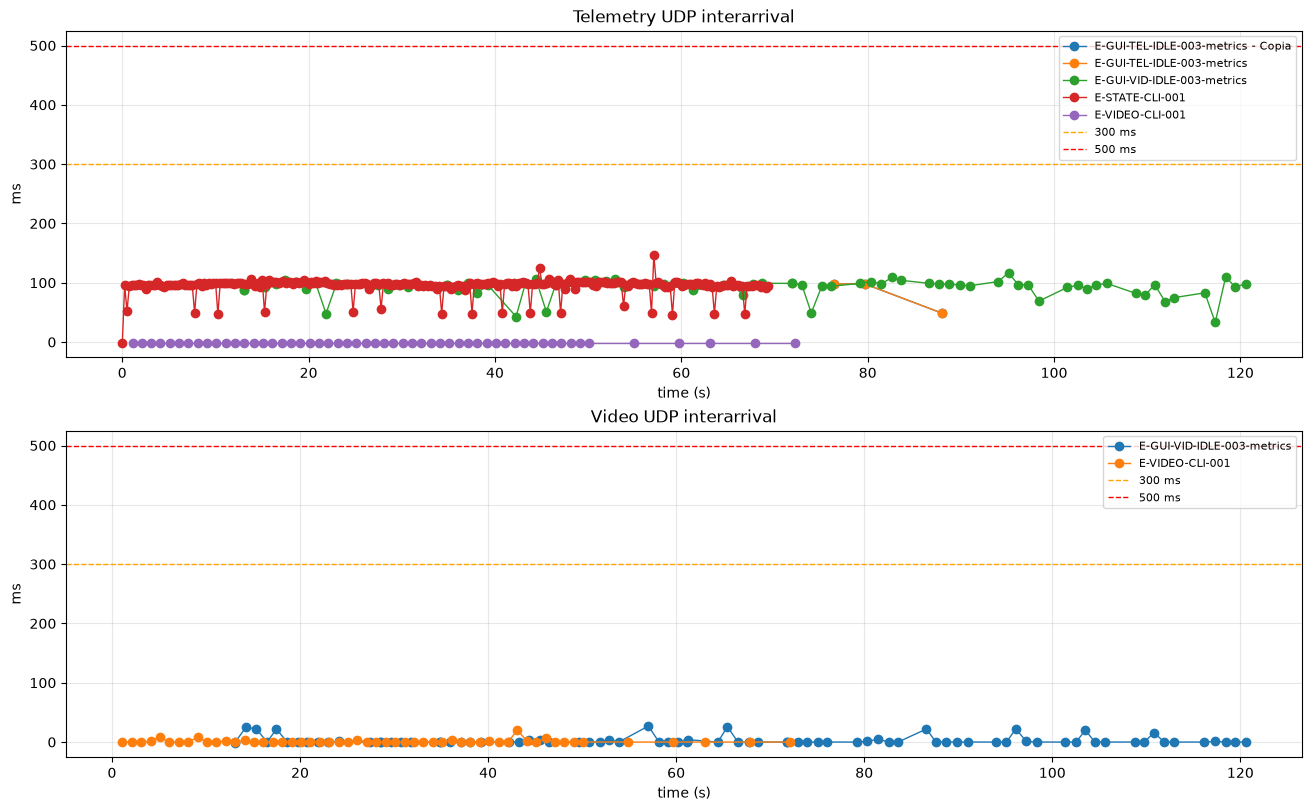

In [7]:
new_metrics = [r for r in metrics_reports if any("telemetry_max_interarrival_ms" in row for row in r["rows"])]

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False, constrained_layout=True)

for r in new_metrics:
    rows = r["rows"]
    x = numeric(rows, "elapsed_ms")
    y = numeric(rows, "telemetry_interarrival_ms")
    if x and y:
        n = min(len(x), len(y))
        axes[0].plot([v/1000 for v in x[:n]], y[:n], marker="o", linewidth=1, label=r["path"].stem)

axes[0].axhline(300, color="orange", linestyle="--", linewidth=1, label="300 ms")
axes[0].axhline(500, color="red", linestyle="--", linewidth=1, label="500 ms")
axes[0].set_title("Telemetry UDP interarrival")
axes[0].set_xlabel("time (s)")
axes[0].set_ylabel("ms")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)

for r in new_metrics:
    rows = r["rows"]
    x = numeric(rows, "elapsed_ms")
    y = numeric(rows, "video_interarrival_ms")
    if x and y and max(y) > 0:
        n = min(len(x), len(y))
        axes[1].plot([v/1000 for v in x[:n]], y[:n], marker="o", linewidth=1, label=r["path"].stem)

axes[1].axhline(300, color="orange", linestyle="--", linewidth=1, label="300 ms")
axes[1].axhline(500, color="red", linestyle="--", linewidth=1, label="500 ms")
axes[1].set_title("Video UDP interarrival")
axes[1].set_xlabel("time (s)")
axes[1].set_ylabel("ms")
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)
plt.show()

## Final Gap Counters By Run

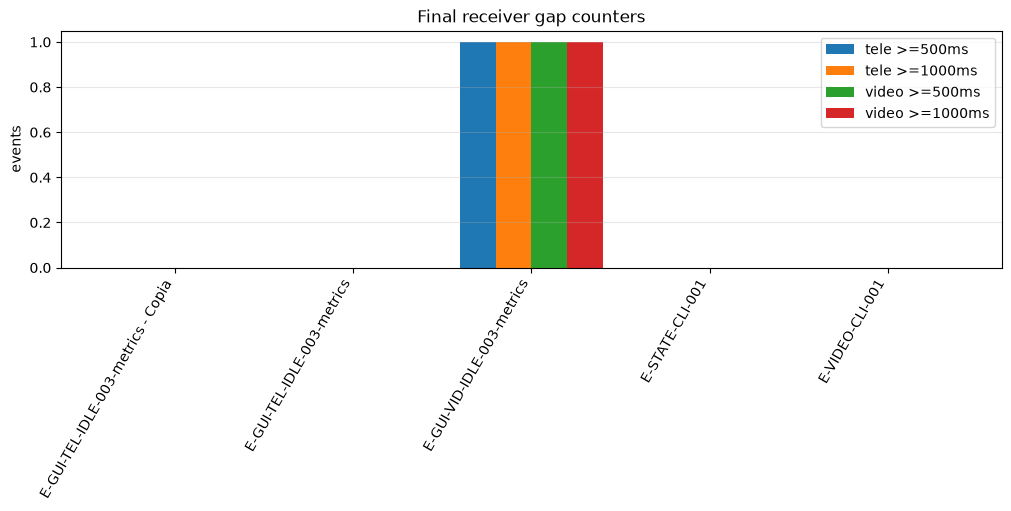

In [8]:
runs = []
tele500 = []
tele1000 = []
vid500 = []
vid1000 = []
for r in new_metrics:
    rows = r["rows"]
    if not rows:
        continue
    runs.append(r["path"].stem)
    tele500.append(last_num(rows, "telemetry_gap_events_500ms", 0))
    tele1000.append(last_num(rows, "telemetry_gap_events_1000ms", 0))
    vid500.append(last_num(rows, "video_gap_events_500ms", 0))
    vid1000.append(last_num(rows, "video_gap_events_1000ms", 0))

if runs:
    x = range(len(runs))
    width = 0.2
    fig, ax = plt.subplots(figsize=(max(10, len(runs)*0.7), 5), constrained_layout=True)
    ax.bar([i - 1.5*width for i in x], tele500, width, label="tele >=500ms")
    ax.bar([i - 0.5*width for i in x], tele1000, width, label="tele >=1000ms")
    ax.bar([i + 0.5*width for i in x], vid500, width, label="video >=500ms")
    ax.bar([i + 1.5*width for i in x], vid1000, width, label="video >=1000ms")
    ax.set_xticks(list(x))
    ax.set_xticklabels(runs, rotation=60, ha="right")
    ax.set_title("Final receiver gap counters")
    ax.set_ylabel("events")
    ax.grid(axis="y", alpha=0.3)
    ax.legend()
    plt.show()
else:
    print("No new-schema metrics files found.")

## Control Panel GUI Performance

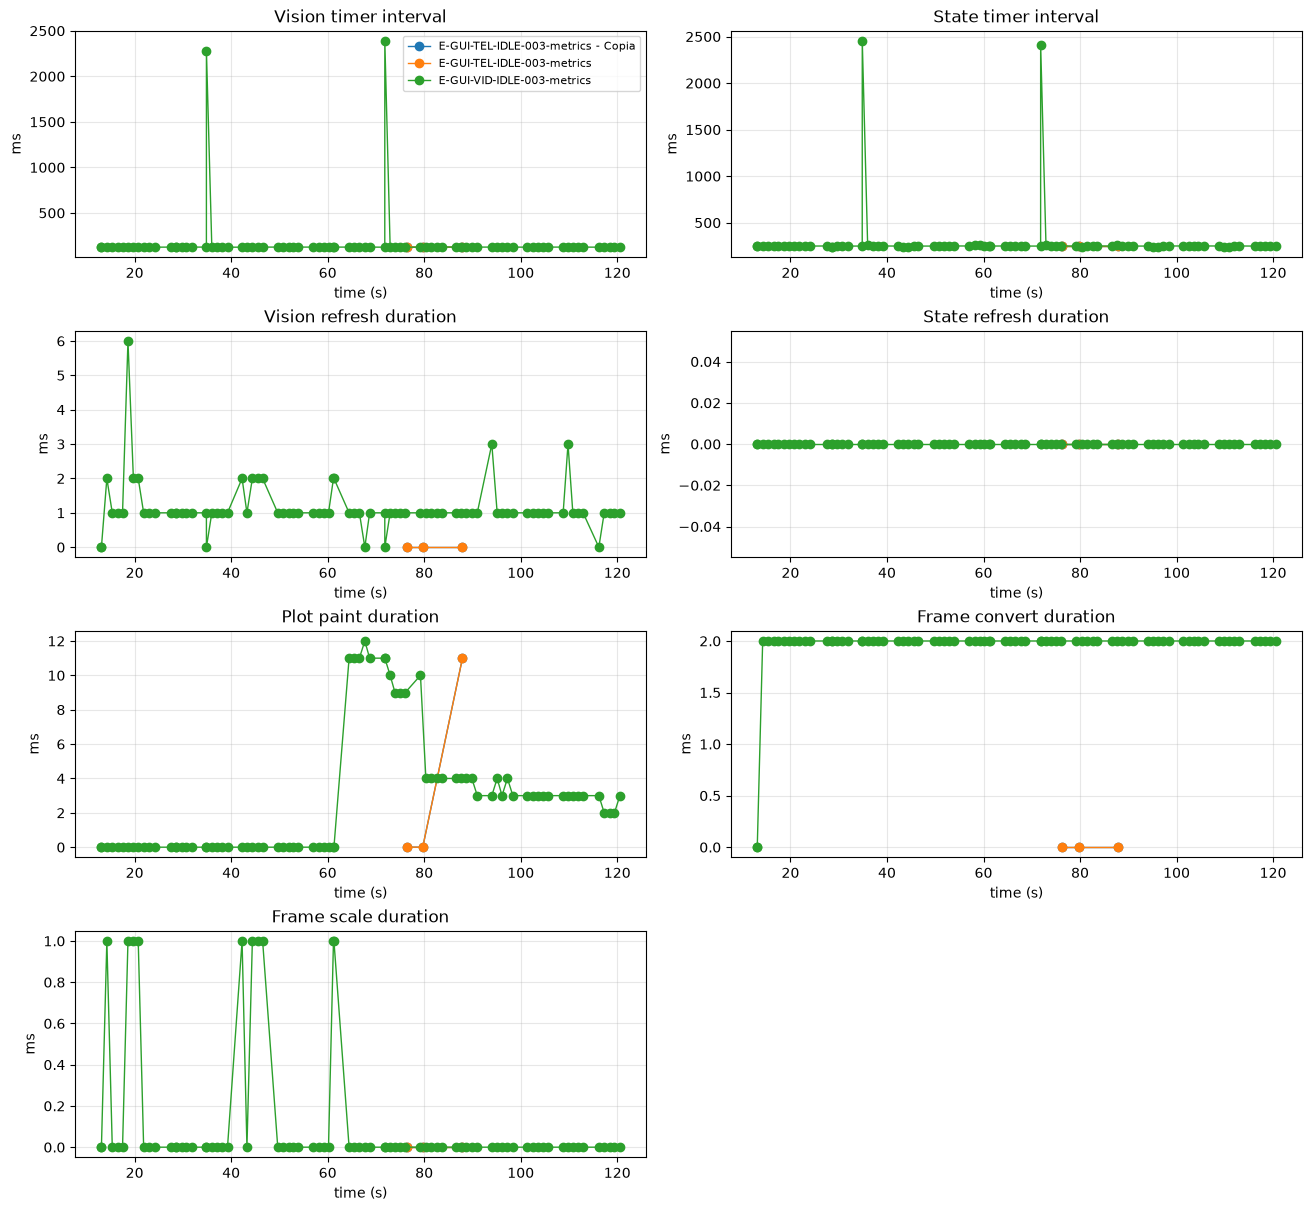

In [9]:
gui_runs = [r for r in new_metrics if any(row.get("run_mode") == "CONTROL_PANEL" for row in r["rows"])]
fields = [
    ("gui_vision_tick_delay_ms", "Vision timer interval"),
    ("gui_state_tick_delay_ms", "State timer interval"),
    ("vision_refresh_duration_ms", "Vision refresh duration"),
    ("state_refresh_duration_ms", "State refresh duration"),
    ("plot_paint_ms", "Plot paint duration"),
    ("frame_convert_ms", "Frame convert duration"),
    ("frame_scale_ms", "Frame scale duration"),
]

if gui_runs:
    fig, axes = plt.subplots(4, 2, figsize=(13, 12), constrained_layout=True)
    axes = axes.ravel()
    for ax, (field, title) in zip(axes, fields):
        for r in gui_runs:
            rows = r["rows"]
            x = numeric(rows, "elapsed_ms")
            y = numeric(rows, field)
            if x and y:
                n = min(len(x), len(y))
                ax.plot([v/1000 for v in x[:n]], y[:n], marker="o", linewidth=1, label=r["path"].stem)
        ax.set_title(title)
        ax.set_xlabel("time (s)")
        ax.set_ylabel("ms")
        ax.grid(True, alpha=0.3)
    axes[-1].axis("off")
    axes[0].legend(fontsize=8)
    plt.show()
else:
    print("No control-panel metrics rows found.")

## State Recording Gap Timeline

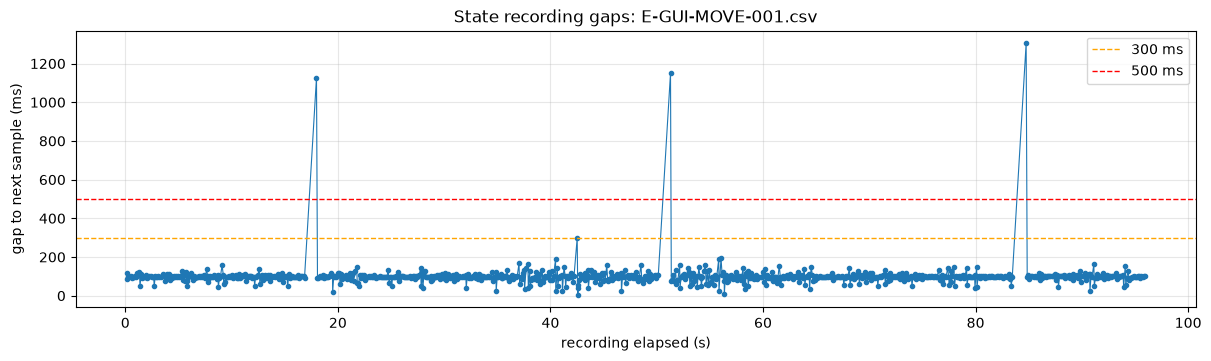

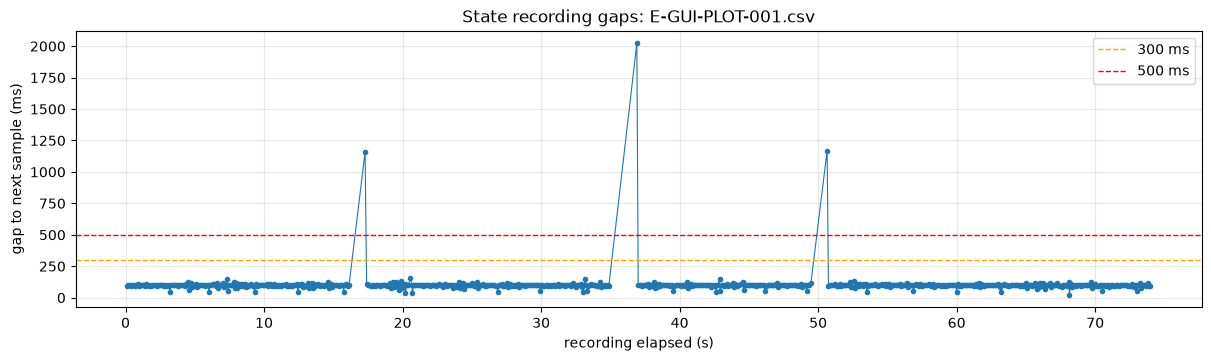

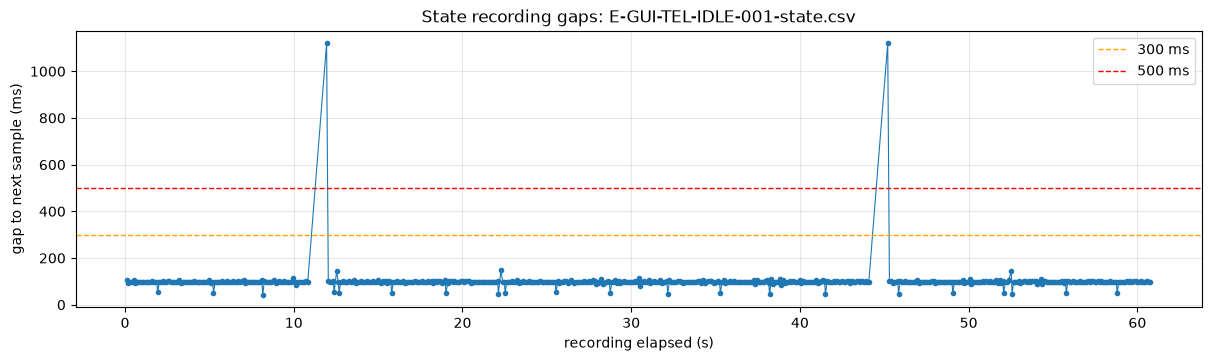

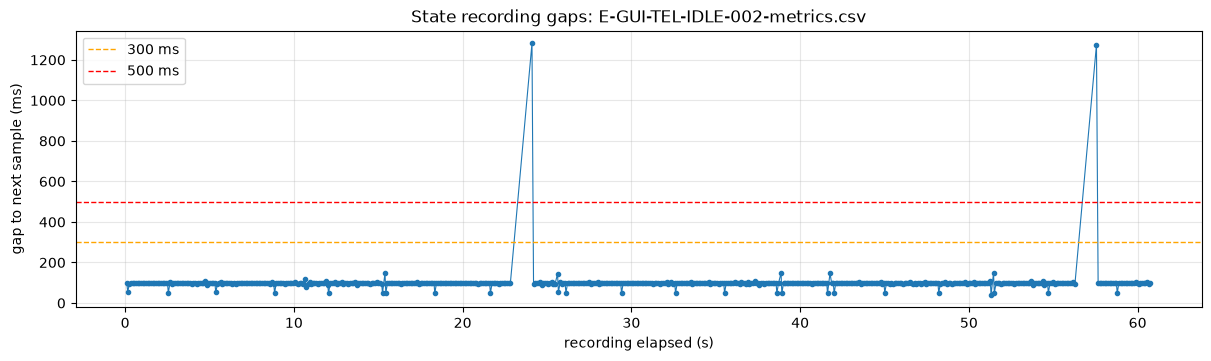

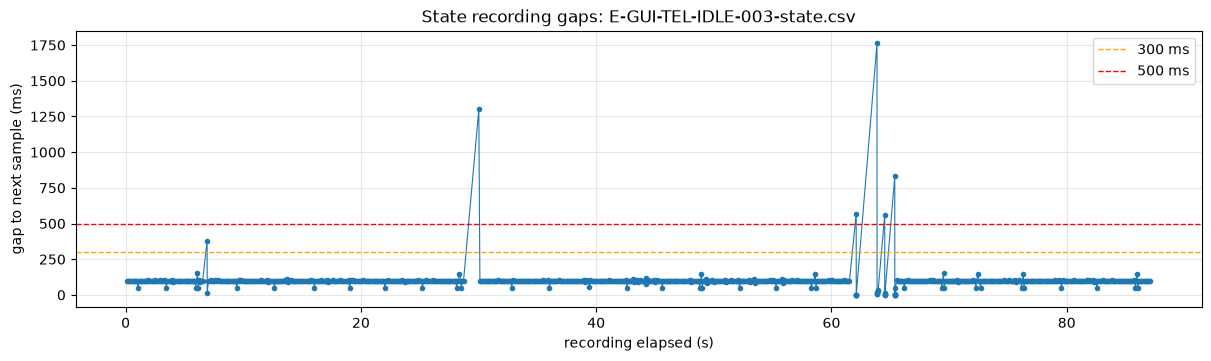

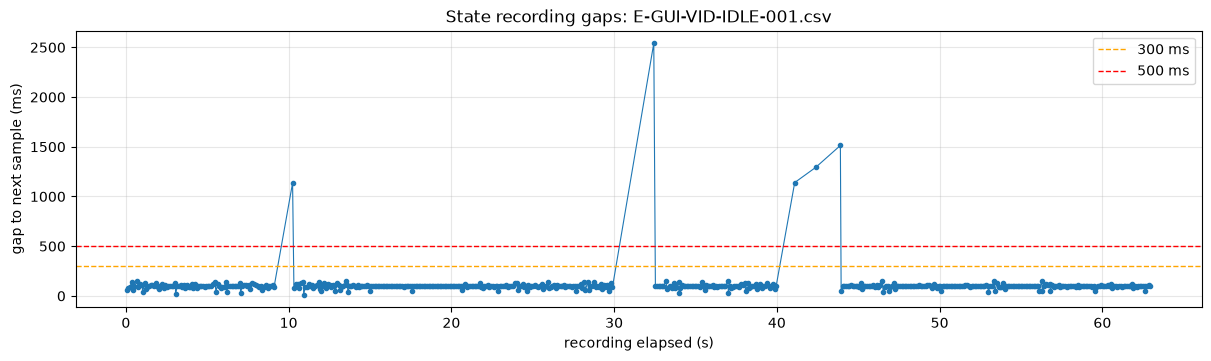

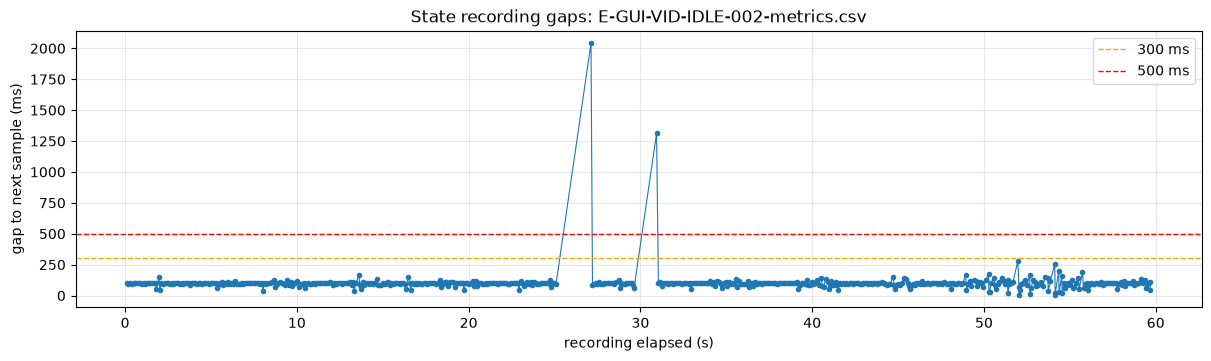

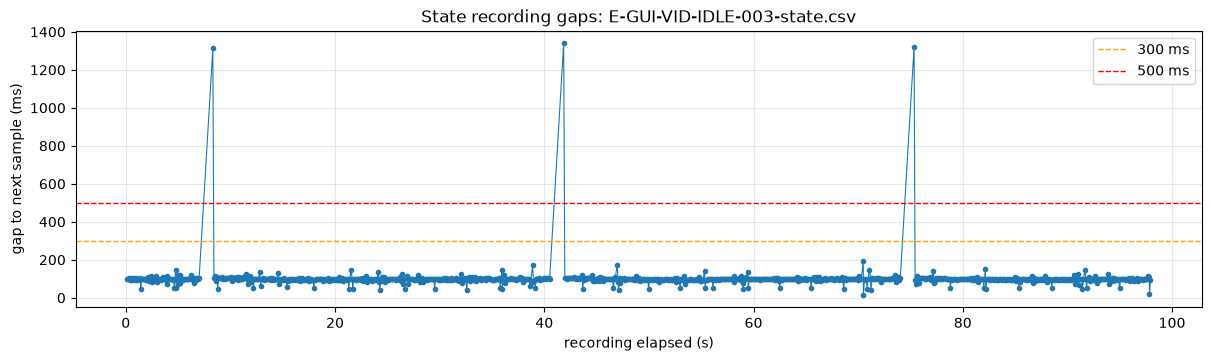

In [10]:
for r in state_reports:
    samples = state_samples(r)
    if len(samples) < 2:
        continue
    xs = [samples[i+1][0] / 1000 for i in range(len(samples)-1)]
    gaps = [samples[i+1][0] - samples[i][0] for i in range(len(samples)-1)]
    fig, ax = plt.subplots(figsize=(12, 3.5), constrained_layout=True)
    ax.plot(xs, gaps, marker=".", linewidth=0.8)
    ax.axhline(300, color="orange", linestyle="--", linewidth=1, label="300 ms")
    ax.axhline(500, color="red", linestyle="--", linewidth=1, label="500 ms")
    ax.set_title(f"State recording gaps: {r['name']}")
    ax.set_xlabel("recording elapsed (s)")
    ax.set_ylabel("gap to next sample (ms)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.show()

## State Values During GUI Experiments

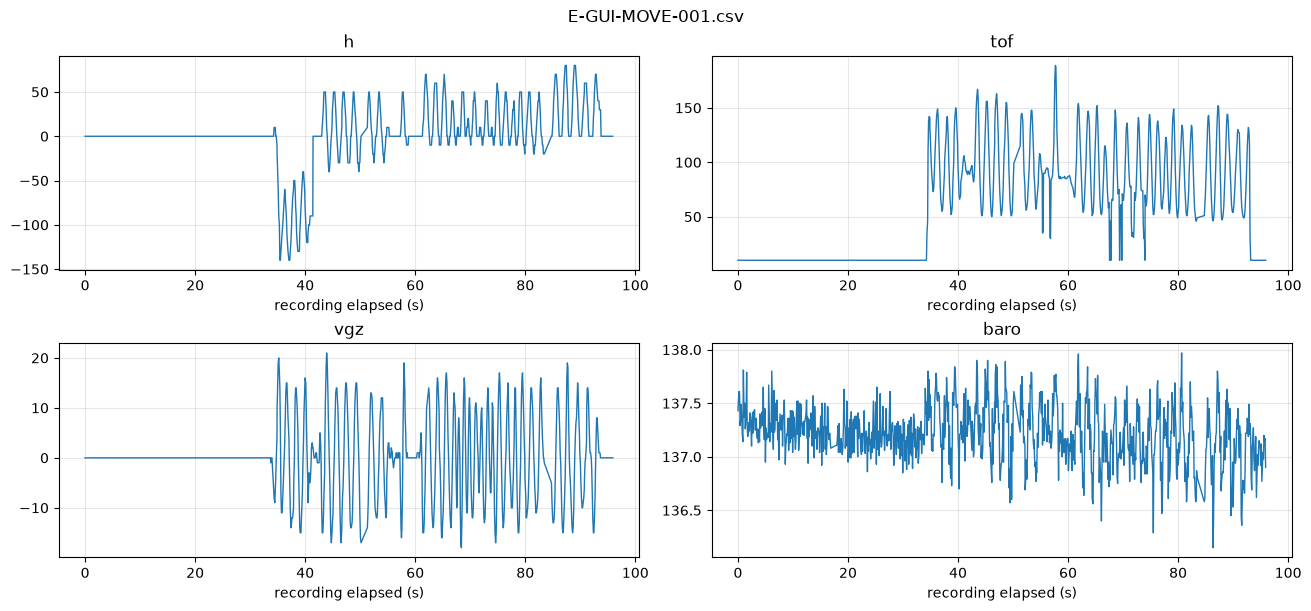

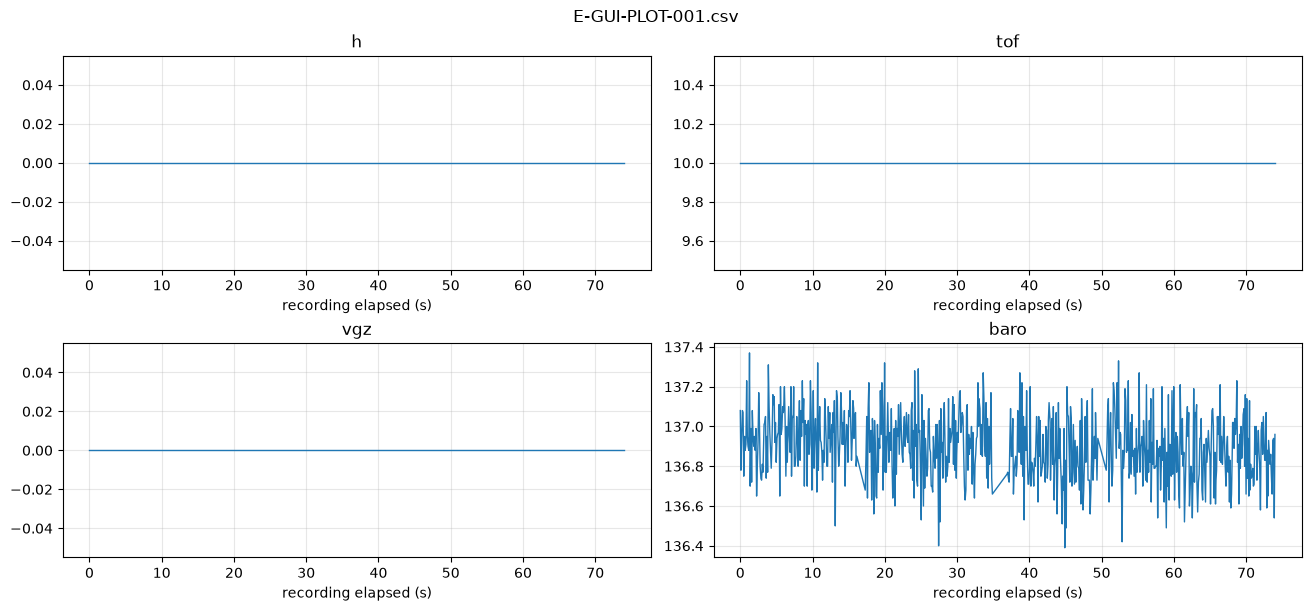

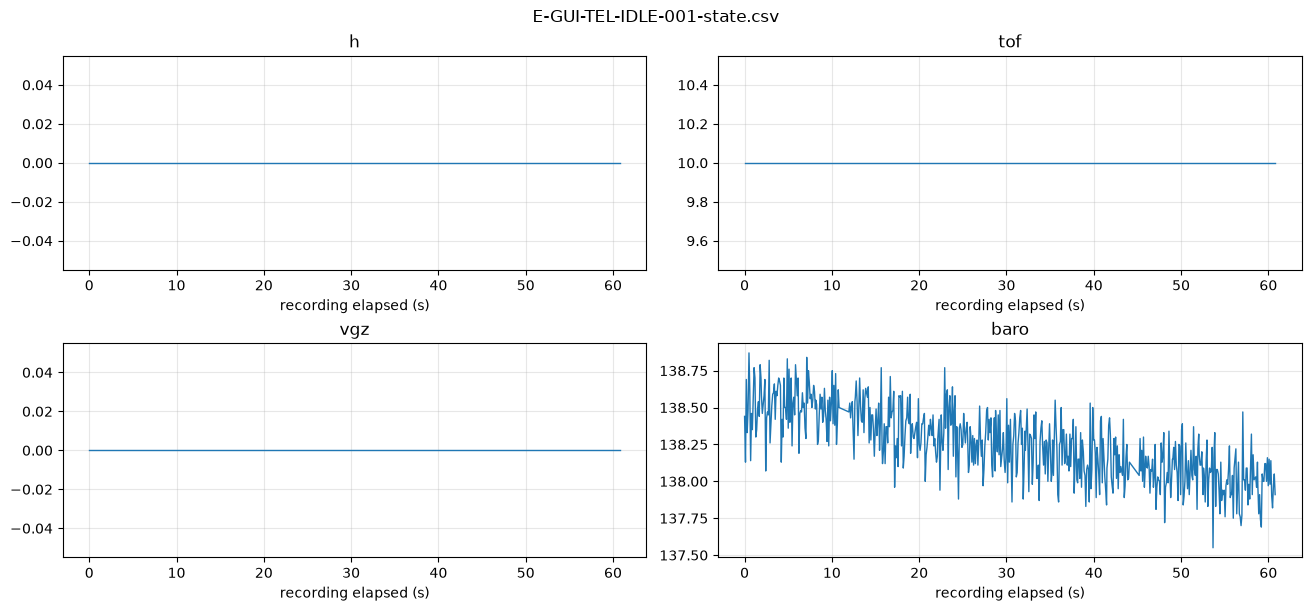

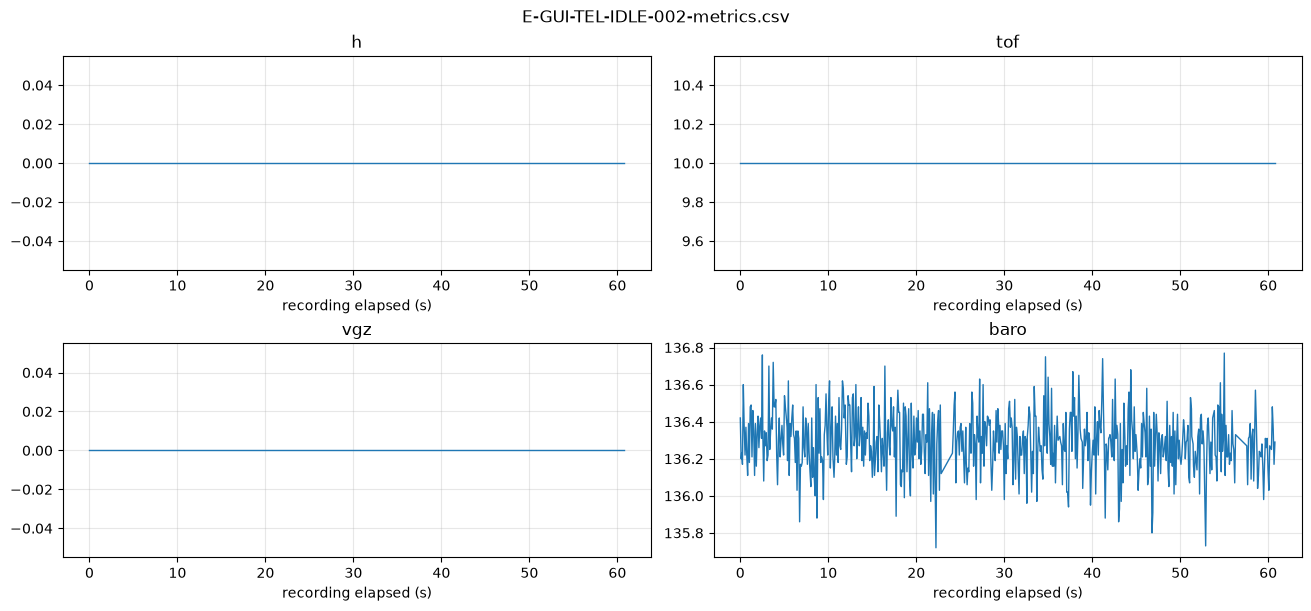

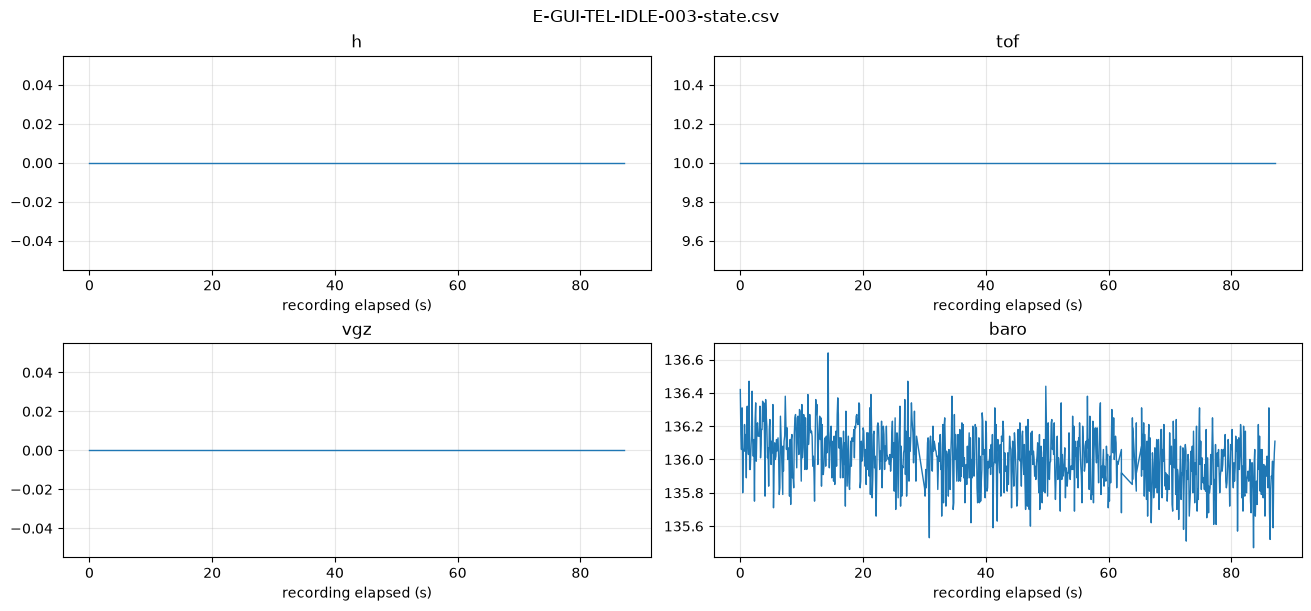

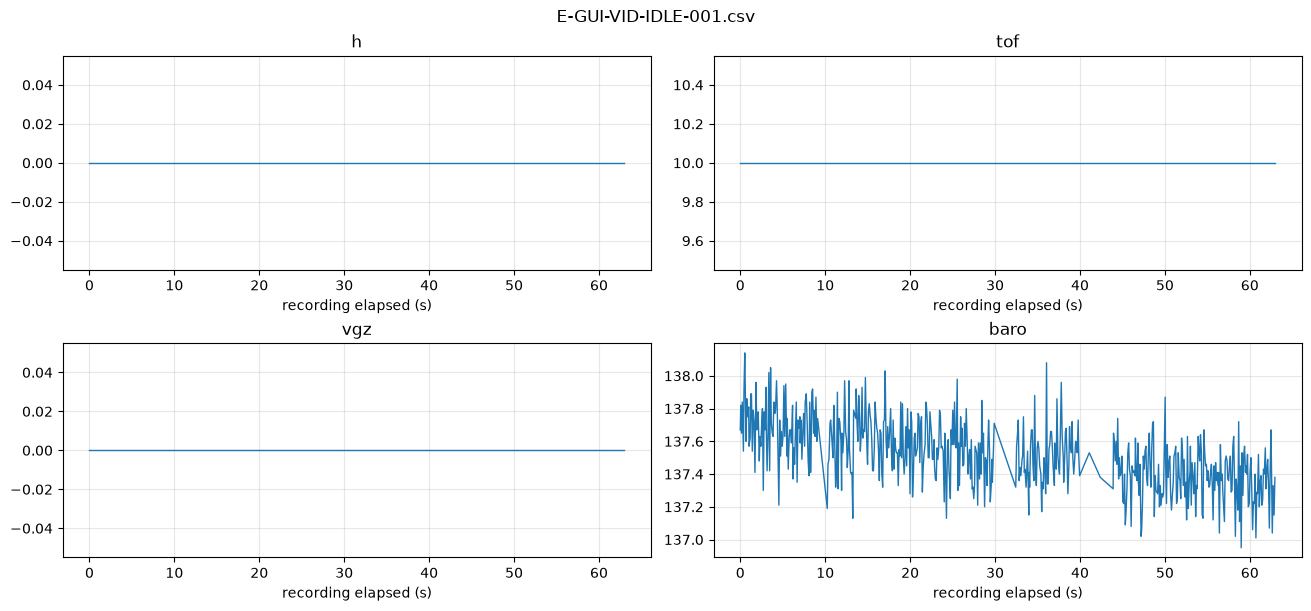

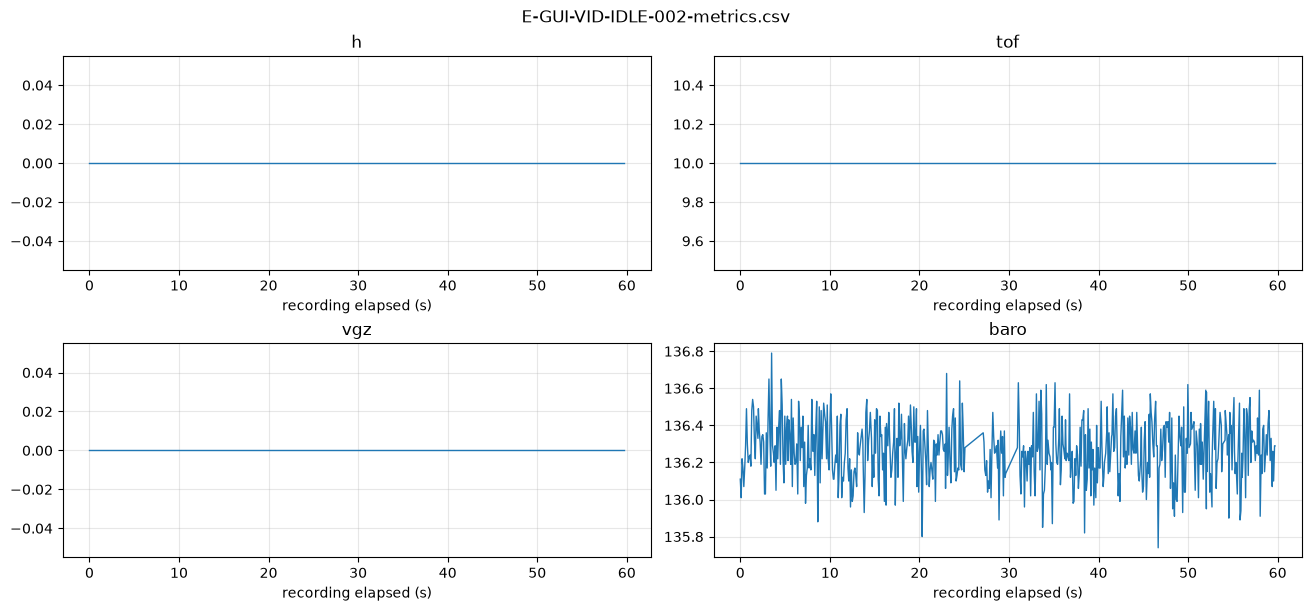

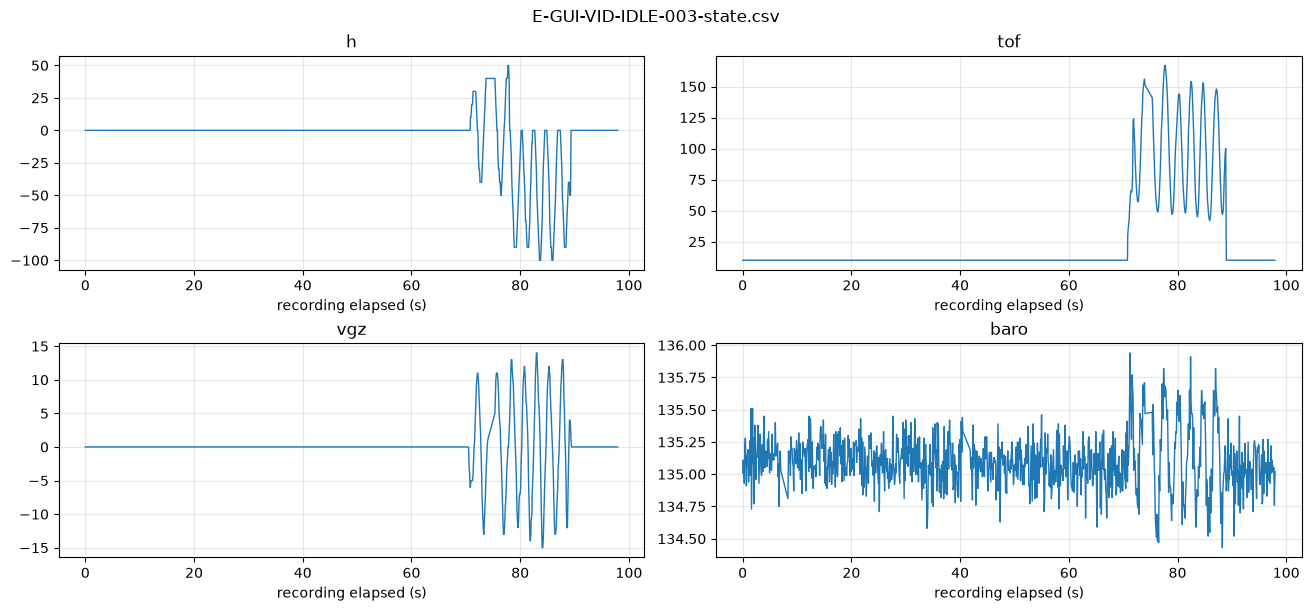

In [11]:
state_value_fields = ["h", "tof", "vgz", "baro"]
interesting_state = [r for r in state_reports if r["path"].stem.startswith("E-GUI")]

for r in interesting_state:
    samples = state_samples(r)
    if not samples:
        continue
    fig, axes = plt.subplots(2, 2, figsize=(13, 6), constrained_layout=True)
    axes = axes.ravel()
    for ax, field in zip(axes, state_value_fields):
        x = [s[0] / 1000 for s in samples]
        y = [to_float(s[2].get(field), None) for s in samples]
        x2 = [xx for xx, yy in zip(x, y) if yy is not None]
        y2 = [yy for yy in y if yy is not None]
        ax.plot(x2, y2, linewidth=1)
        ax.set_title(field)
        ax.set_xlabel("recording elapsed (s)")
        ax.grid(True, alpha=0.3)
    fig.suptitle(r["name"])
    plt.show()

## Recovery Events

In [12]:
recovery_rows = []
for r in metrics_reports:
    for row in r["rows"]:
        if row.get("recovery_attempted") in ("1", "1.0"):
            recovery_rows.append([
                r["name"],
                row.get("elapsed_ms", ""),
                row.get("recovery_stage", ""),
                row.get("recovery_result", ""),
                row.get("recovery_hard", ""),
                row.get("recovery_command_channel_available", ""),
                row.get("video_age_ms", ""),
                row.get("connection_state", ""),
            ])

if recovery_rows:
    show_markdown(md_table([
        "file", "elapsed_ms", "stage", "result", "hard", "cmd_channel", "video_age_ms", "state",
    ], recovery_rows))
else:
    print("No recovery attempts found.")

| file | elapsed_ms | stage | result | hard | cmd_channel | video_age_ms | state |
|---|---|---|---|---|---|---|---|
| E-PWR-CYCLE-001.csv | 21918 | power_command | TIMEOUT | 1 | 0 | 3793 | RECOVERING |
| E-PWR-CYCLE-001.csv | 26718 | power_command | TIMEOUT | 1 | 0 | 8590 | RECOVERING |
| E-PWR-CYCLE-001.csv | 30814 | power_command | TIMEOUT | 1 | 0 | 13390 | RECOVERING |
| E-PWR-CYCLE-001.csv | 33377 | power_streamon | OK | 1 | 1 | 17486 | CONNECTED |
| E-VID-RESET-001.csv | 20031 | streamon | OK | 0 | 1 | 3789 | CONNECTED |
| E-VID-RESET-001.csv | 26834 | power_command | TIMEOUT | 1 | 0 | 6790 | RECOVERING |
| E-VID-RESET-001.csv | 27834 | streamon | OK | 0 | 1 | 11592 | CONNECTED |
| E-VIDEO-CLI-001.csv | 54905 | power_command | TIMEOUT | 1 | 0 | 3383 | RECOVERING |
| E-VIDEO-CLI-001.csv | 59705 | power_command | TIMEOUT | 1 | 0 | 8171 | RECOVERING |
| E-VIDEO-CLI-001.csv | 63097 | power_command | TIMEOUT | 1 | 0 | 12971 | RECOVERING |
| E-VIDEO-CLI-001.csv | 67901 | power_command | TIMEOUT | 1 | 0 | 16363 | RECOVERING |
| E-VIDEO-CLI-001.csv | 72153 | power_command | TIMEOUT | 1 | 0 | 21173 | RECOVERING |

## Plot Metric Change Events

In [13]:
plot_events = []
for r in metrics_reports:
    for row in r["rows"]:
        event = row.get("event", "")
        if event.startswith("plot_metric_changed"):
            plot_events.append([
                r["name"],
                row.get("elapsed_ms", ""),
                event,
                row.get("plot_metric", ""),
                row.get("telemetry_gap_events_500ms", ""),
                row.get("video_gap_events_500ms", ""),
                row.get("plot_paint_ms", ""),
            ])

if plot_events:
    show_markdown(md_table([
        "file", "elapsed_ms", "event", "plot_metric", "tele_gap500", "video_gap500", "plot_paint_ms",
    ], plot_events))
else:
    print("No plot metric change events found in metrics CSVs.")

| file | elapsed_ms | event | plot_metric | tele_gap500 | video_gap500 | plot_paint_ms |
|---|---|---|---|---|---|---|
| E-GUI-TEL-IDLE-003-metrics - Copia.csv | 76336 | plot_metric_changed:tof | tof | 0 | 0 | 0 |
| E-GUI-TEL-IDLE-003-metrics - Copia.csv | 79695 | plot_metric_changed:baro | baro | 0 | 0 | 0 |
| E-GUI-TEL-IDLE-003-metrics - Copia.csv | 87925 | plot_metric_changed:vgz | vgz | 0 | 0 | 11 |
| E-GUI-TEL-IDLE-003-metrics.csv | 76336 | plot_metric_changed:tof | tof | 0 | 0 | 0 |
| E-GUI-TEL-IDLE-003-metrics.csv | 79695 | plot_metric_changed:baro | baro | 0 | 0 | 0 |
| E-GUI-TEL-IDLE-003-metrics.csv | 87925 | plot_metric_changed:vgz | vgz | 0 | 0 | 11 |
| E-GUI-VID-IDLE-003-metrics.csv | 28512 | plot_metric_changed:yaw | yaw | 0 | 0 | 0 |
| E-GUI-VID-IDLE-003-metrics.csv | 34878 | plot_metric_changed:tof | tof | 0 | 0 | 0 |
| E-GUI-VID-IDLE-003-metrics.csv | 61201 | plot_metric_changed:baro | baro | 0 | 0 | 0 |
| E-GUI-VID-IDLE-003-metrics.csv | 71839 | plot_metric_changed:agy | agy | 0 | 0 | 11 |

## Automated Findings

In [14]:
findings = []

cli_state = [r for r in metrics_reports if "STATE-CLI" in r["name"]]
for r in cli_state:
    rows = r["rows"]
    if rows:
        findings.append(
            f"`{r['name']}`: CLI telemetry max interarrival = "
            f"{int(max_num(rows, 'telemetry_max_interarrival_ms', 0))} ms, "
            f"gap>=500 events = {int(last_num(rows, 'telemetry_gap_events_500ms', 0))}."
        )

for r in metrics_reports:
    rows = r["rows"]
    if not rows:
        continue
    tele500 = int(last_num(rows, "telemetry_gap_events_500ms", 0))
    video500 = int(last_num(rows, "video_gap_events_500ms", 0))
    if tele500 > 0 and video500 > 0:
        findings.append(
            f"`{r['name']}`: telemetry and video both have >=500 ms gap events "
            f"(tele={tele500}, video={video500}), which points toward Wi-Fi/system/network pauses."
        )
    elif tele500 > 0:
        findings.append(
            f"`{r['name']}`: telemetry has >=500 ms gaps but video does not, suggesting a telemetry-specific path issue."
        )

for sr in state_reports:
    samples = state_samples(sr)
    st = gap_stats(samples)
    if st["g500"] <= 0:
        continue
    stem = sr["path"].stem.replace("-state", "").replace("-metrics", "")
    possible_metrics = [mr for mr in metrics_reports if stem in mr["path"].stem or mr["path"].stem in stem]
    if possible_metrics:
        mr = possible_metrics[-1]
        tele500 = int(last_num(mr["rows"], "telemetry_gap_events_500ms", 0)) if mr["rows"] else 0
        if tele500 == 0:
            findings.append(
                f"`{sr['name']}` has state-recording gaps >=500 ms, but matching metrics file "
                f"`{mr['name']}` has no telemetry receiver gap>=500. This suggests recording/export path artifacts."
            )

if findings:
    show_markdown("\n".join(f"- {f}" for f in findings))
else:
    print("No automated findings triggered. Inspect plots and tables above.")

- `E-STATE-CLI-001.csv`: CLI telemetry max interarrival = 151 ms, gap>=500 events = 0.
- `E-GUI-VID-IDLE-003-metrics.csv`: telemetry and video both have >=500 ms gap events (tele=1, video=1), which points toward Wi-Fi/system/network pauses.
- `E-GUI-TEL-IDLE-001-state.csv` has state-recording gaps >=500 ms, but matching metrics file `E-GUI-TEL-IDLE-001.csv` has no telemetry receiver gap>=500. This suggests recording/export path artifacts.
- `E-GUI-TEL-IDLE-003-state.csv` has state-recording gaps >=500 ms, but matching metrics file `E-GUI-TEL-IDLE-003-metrics.csv` has no telemetry receiver gap>=500. This suggests recording/export path artifacts.

## Report Notes

Use these notebook outputs in the final report:

1. **Command reliability**: command failures and latency from command baseline runs.
2. **Telemetry continuity**: max interarrival and gap counters from CLI and GUI runs.
3. **Video continuity**: video interarrival and video gap counters.
4. **GUI/rendering health**: GUI timer delays and paint/convert/scale timings.
5. **State recording quality**: recording gap timelines and malformed-row warnings.
6. **Recovery behavior**: recovery stages, results, and whether packet counters resumed.

For the current investigation, the strongest evidence is usually the contrast between:

- `E-STATE-CLI-*` telemetry receiver gaps,
- `E-GUI-*-metrics` telemetry/video receiver gaps,
- `E-GUI-*-state` state recording gaps.

If receiver gaps are low but state recording gaps are high, the issue is probably not Wi-Fi; it is more likely recording/export behavior. If telemetry and video receiver gaps rise together, the issue is more likely Wi-Fi, driver, or system/network scheduling.